In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import time

In [6]:
df_reduced = pd.read_csv('reduced_tuesday_bruteforce_columns_2.csv', sep = ',')
for i, col in enumerate(df_reduced.columns):
    print(i, repr(col))
print(f"\nKích thước dataset cuối cùng: {df_reduced.shape}")

0 'flow duration'
1 'flow iat mean'
2 'flow iat std'
3 'flow iat max'
4 'flow iat min'
5 'fwd iat mean'
6 'fwd iat std'
7 'total fwd packets'
8 'total backward packets'
9 'fwd packet length mean'
10 'fwd packet length std'
11 'bwd packet length mean'
12 'bwd packet length std'
13 'flow packets/s'
14 'flow bytes/s'
15 'fwd psh flags'
16 'ack flag count'
17 'syn flag count'
18 'fin flag count'
19 'init_win_bytes_forward'
20 'init_win_bytes_backward'
21 'label'

Kích thước dataset cuối cùng: (27660, 22)


In [7]:
#split X(features) and y(label)
X = df_reduced.drop('label', axis=1)
y = df_reduced['label']

#label encoding to number(BENIGN -> 0, FTP -> 1, SSH -> 2)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("\nLabel mapping: ")
for i, label in enumerate(le.classes_):
    print(f"{label} -> {i}")


#split train/test set (80% train, 20% test)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y_encoded, test_size = 0.2,
                                                             random_state = 42, stratify = y_encoded) 


#normalization
#use MinMaxScaler to take data about [0, 1] (necessary for running IPS stably )
scaler = MinMaxScaler()

#fit train and test on train and transform
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)



Label mapping: 
BENIGN -> 0
FTP-Patator -> 1
SSH-Patator -> 2


--- BẮT ĐẦU SO SÁNH HIỆU NĂNG ---

>> Đang huấn luyện: Random Forest...
-> Hoàn tất Random Forest!
   + Thời gian train: 1.4716 giây
   + Độ chính xác:    99.9096%

>> Đang huấn luyện: XGBoost...
-> Hoàn tất XGBoost!
   + Thời gian train: 0.3212 giây
   + Độ chính xác:    99.9458%

     BÁO CÁO CHI TIẾT SO SÁNH

*** MÔ HÌNH: Random Forest ***
Accuracy: 99.9096%
Classification Report:
              precision    recall  f1-score   support

      BENIGN     0.9989    0.9993    0.9991      2766
 FTP-Patator     0.9994    0.9994    0.9994      1587
 SSH-Patator     0.9992    0.9983    0.9987      1179

    accuracy                         0.9991      5532
   macro avg     0.9991    0.9990    0.9991      5532
weighted avg     0.9991    0.9991    0.9991      5532

------------------------------

*** MÔ HÌNH: XGBoost ***
Accuracy: 99.9458%
Classification Report:
              precision    recall  f1-score   support

      BENIGN     0.9996    0.9993    0.9995      2766
 FTP-Patator     0.9994 

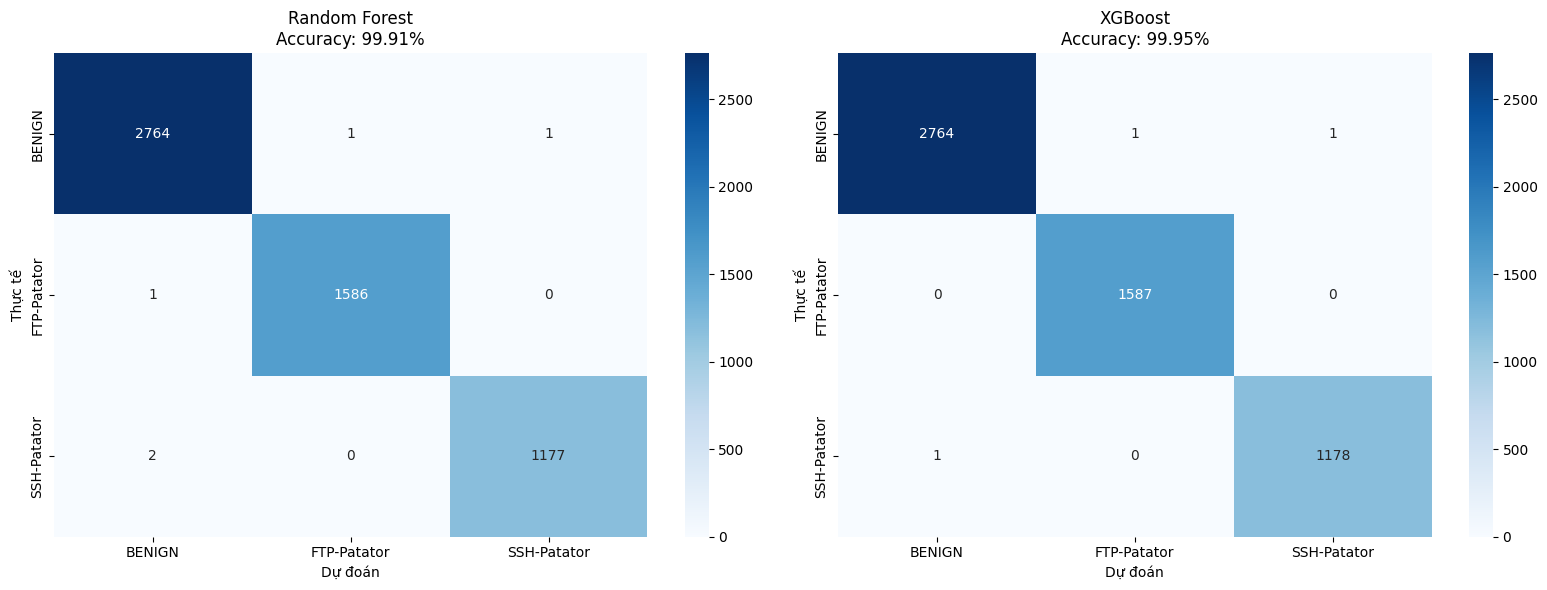

In [8]:


# ==========================================
# CẤU HÌNH 2 MÔ HÌNH ĐỂ SO SÁNH
# ==========================================
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', random_state=42)
}

# Lưu kết quả để vẽ biểu đồ sau này
results = {}

print("--- BẮT ĐẦU SO SÁNH HIỆU NĂNG ---")

for name, model in models.items():
    print(f"\n>> Đang huấn luyện: {name}...")
    
    # 1. Đo thời gian huấn luyện (Training Time)
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    # 2. Dự đoán và đo thời gian dự đoán (Prediction Time)
    # Đây là chỉ số quan trọng cho IPS (độ trễ thấp)
    start_pred = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - start_pred
    
    # 3. Tính toán các chỉ số
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=le.classes_, digits=4)
    cm = confusion_matrix(y_test, y_pred)
    
    # Lưu lại kết quả
    results[name] = {
        "accuracy": acc,
        "train_time": train_time,
        "pred_time": pred_time,
        "confusion_matrix": cm,
        "report": report
    }
    
    print(f"-> Hoàn tất {name}!")
    print(f"   + Thời gian train: {train_time:.4f} giây")
    print(f"   + Độ chính xác:    {acc*100:.4f}%")

# ==========================================
# HIỂN THỊ CHI TIẾT ĐỂ SO SÁNH
# ==========================================
print("\n" + "="*40)
print("     BÁO CÁO CHI TIẾT SO SÁNH")
print("="*40)

for name, res in results.items():
    print(f"\n*** MÔ HÌNH: {name} ***")
    print(f"Accuracy: {res['accuracy']*100:.4f}%")
    print("Classification Report:")
    print(res['report'])
    print("-" * 30)

# ==========================================
# VẼ BIỂU ĐỒ SO SÁNH TRỰC QUAN (CONFUSION MATRIX)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (name, res) in enumerate(results.items()):
    sns.heatmap(res['confusion_matrix'], annot=True, fmt='d', cmap='Blues', 
                xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[i])
    axes[i].set_title(f'{name}\nAccuracy: {res["accuracy"]*100:.2f}%')
    axes[i].set_ylabel('Thực tế')
    axes[i].set_xlabel('Dự đoán')

plt.tight_layout()
plt.show()